In [1]:
%pip install matplotlib requests moviepy


Note: you may need to restart the kernel to use updated packages.


# V17b3 — bounded audit of the interrupted stabilized scalar run

V17b2 was numerically healthy but expensive: it saved 5,000 accepted updates,
one complete repetition boundary, and a second checkpoint before interruption.
Its final 250-update training median is about 0.503, far above the registered
0.212 material-progress threshold, but training batches cannot replace the
unopened stochastic audit.

This notebook performs no optimization. It evaluates steps 4,000 and 5,000 on
the original V17b2 selection seeds, locks one checkpoint, then opens the
original disjoint sixteen-seed audit. The result decides whether one bounded
continuation is justified or the scalar GradNorm branch should close.

Upload `v17b2_stabilized_capacity_iso_port.zip`, run all cells on CUDA, and
download `v17b3_bounded_interrupted_checkpoint_audit_artifacts.tar.gz`.


In [2]:
VERSION = 'V17b3'
SLUG = 'v17b3_bounded_interrupted_checkpoint_audit'


In [3]:
#@title Load the interrupted V17b2 artifact and exact training source
from io import BytesIO
from pathlib import Path
import hashlib
import importlib.util
import json
import os
import random
import subprocess
import sys
import tarfile
import zipfile

WORKSPACE_ROOT = Path('/workspace') if Path('/workspace').is_dir() else Path.cwd()
SOURCE_NAME = 'v17b2_stabilized_capacity_iso_port.zip'
source_candidates = [
    WORKSPACE_ROOT / SOURCE_NAME,
    Path.cwd() / SOURCE_NAME,
    Path.cwd() / 'notebooks-executed/v17b2' / SOURCE_NAME,
]
SOURCE_PATH = next((path.resolve() for path in source_candidates if path.is_file()), None)
if SOURCE_PATH is None:
    raise FileNotFoundError('Upload ' + SOURCE_NAME + ' into ' + str(WORKSPACE_ROOT))

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

SOURCE_ROOT = WORKSPACE_ROOT / (SLUG + '_source')
SOURCE_ROOT.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(SOURCE_PATH) as archive:
    by_name = {Path(name).name: name for name in archive.namelist()
               if not name.endswith('/')}
    required = {'config.json', 'latest_resume.pt', 'model_rep1.pth', 'decoder_rep1.pth'}
    if not required <= by_name.keys():
        raise RuntimeError('V17b2 ZIP is missing: ' + str(sorted(required - by_name.keys())))
    source_config = json.loads(archive.read(by_name['config.json']))
    for name in ('latest_resume.pt', 'model_rep1.pth', 'decoder_rep1.pth'):
        (SOURCE_ROOT / name).write_bytes(archive.read(by_name[name]))
    first_time = archive.getinfo(by_name['config.json']).date_time
    last_time = archive.getinfo(by_name['latest_resume.pt']).date_time

repo_candidates = [Path.cwd(), WORKSPACE_ROOT / 'Cells2Pixels']
repo_path = next((path.resolve() for path in repo_candidates
                  if (path / 'models/isonca.py').is_file()), None)
if repo_path is None:
    repo_path = (WORKSPACE_ROOT / 'Cells2Pixels').resolve()
    subprocess.run([
        'git', 'clone', '--branch', 'isotropic', '--single-branch',
        'https://github.com/IvanLudvig/Cells2Pixels.git', str(repo_path)], check=True)
os.chdir(repo_path)
if str(repo_path) not in sys.path:
    sys.path.insert(0, str(repo_path))
if importlib.util.find_spec('lpips') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'lpips'], check=True)

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
import torch.nn.functional as F
from PIL import Image
from lpips import LPIPS
from torch.utils.checkpoint import checkpoint

from losses.image_loss import ImageLoss
from losses.invariant_image_loss import InvariantImageLoss
from models.isotropic_lppn import _sine_mlp
from models.isonca import GradNormIsoGrowingNCA

if not torch.cuda.is_available():
    raise RuntimeError('A CUDA GPU runtime is required for the checkpoint audit')
device = torch.device('cuda')
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

TARGET_IMAGE_PATH = Path('data/morphology_png/lizard.png')
if not TARGET_IMAGE_PATH.is_file():
    response = requests.get(
        'https://github.com/googlefonts/noto-emoji/blob/main/png/512/emoji_u1f98e.png?raw=true',
        headers={'User-Agent': 'Cells2Pixels V17b3'}, timeout=60)
    response.raise_for_status()
    TARGET_IMAGE_PATH.parent.mkdir(parents=True, exist_ok=True)
    Image.open(BytesIO(response.content)).convert('RGBA').save(TARGET_IMAGE_PATH)

if file_hash(TARGET_IMAGE_PATH) != source_config['target_hash']:
    raise RuntimeError('V17b2 artifact and local lizard target hashes differ')
expected_sources = source_config.get('repository_sources', {})
actual_sources = {name: file_hash(repo_path / name) for name in expected_sources}
source_mismatches = {name: (expected_sources[name], actual_sources[name])
                     for name in expected_sources if expected_sources[name] != actual_sources[name]}
if source_mismatches:
    raise RuntimeError('Repository sources differ from the executed V17b2 run: '
                       + str(source_mismatches))

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

OUTPUT_ROOT = WORKSPACE_ROOT / SLUG
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
ARCHIVE_PATH = WORKSPACE_ROOT / (SLUG + '_artifacts.tar.gz')
print('Repository:', repo_path)
print('V17b2 ZIP:', SOURCE_PATH, file_hash(SOURCE_PATH)[:12])
print('Output:', OUTPUT_ROOT)
print('GPU:', torch.cuda.get_device_name(0), '| Torch:', torch.__version__)


Repository: /workspace/Cells2Pixels
V17b2 ZIP: /workspace/v17b2_stabilized_capacity_iso_port.zip 47865fa07c15
Output: /workspace/v17b3_bounded_interrupted_checkpoint_audit
GPU: NVIDIA GeForce RTX 3060 Ti | Torch: 2.11.0+cu128


In [4]:
#@title Bounded checkpoint-audit protocol
CHANNELS = int(source_config['channels'])
FC_DIM = int(source_config['fc_dim'])
GRID_SIZE = int(source_config['grid_size'])
RENDER_SCALE = int(source_config['render_scale'])
SELECTION_SEEDS = tuple(source_config['selection_seeds'])
AUDIT_SEEDS = tuple(source_config['audit_seeds'])
SELECTION_AGES = tuple(source_config['selection_ages'])
AUDIT_AGES = tuple(source_config['audit_ages'])
BASE_SEED = int(source_config['base_seed'])
SHARP_MEAN_LIMIT = float(source_config['gates']['sharp_mean'])
SHARP_WORST_LIMIT = float(source_config['gates']['sharp_worst'])
EARLY_QUALITY_LIMIT = float(source_config['gates']['early_quality'])
PERSISTENCE_RATIO_LIMIT = float(source_config['gates']['persistence_ratio'])
DECODER_D4_LIMIT = float(source_config['gates']['decoder_d4'])
PATHWISE_D4_LIMIT = float(source_config['gates']['pathwise_d4'])
PROGRESS_LIMIT = float(source_config['gates']['material_progress'])
V14A_QUALITY = float(source_config['v14a_quality'])
V14C_AGE128_QUALITY = 0.424432

assert GRID_SIZE * RENDER_SCALE == 384
assert set(SELECTION_SEEDS).isdisjoint(AUDIT_SEEDS)
image_loss = ImageLoss(
    target_path=str(TARGET_IMAGE_PATH), image_size=(256, 256),
    padding=(64, 64), l1_weight=1.0, l2_weight=1.0,
    lpips_weight=0.0, premultiply_alpha=True, device=device)
alignment_loss = InvariantImageLoss(
    target_path=str(TARGET_IMAGE_PATH), image_size=(256, 256),
    padding=(64, 64), premultiply_alpha=True, aux_type='noaux',
    mirror=True, sharpen=True, l2_weight=1.0,
    include_nca_alpha=True, device=device)
lpips_loss = LPIPS(net='vgg', verbose=False).to(device).eval()
lpips_loss.requires_grad_(False)
canonical_target = image_loss.target_image.detach()
assert canonical_target.shape == (1, 4, 384, 384)

config = dict(
    protocol='v17b3_bounded_interrupted_checkpoint_audit_v1',
    source_zip=SOURCE_NAME, source_hash=file_hash(SOURCE_PATH),
    source_protocol=source_config['protocol'],
    candidates=['rep1_step4000', 'latest_step5000'],
    checkpoint_selection=(
        'lowest age-128 quality on the original eight unopened selection seeds; '
        'mean multi-age quality breaks ties'),
    final_audit='original sixteen disjoint unopened V17b2 audit seeds',
    gates=source_config['gates'], target_hash=file_hash(TARGET_IMAGE_PATH),
    repository_revision=source_config['repository_revision'],
    repository_sources=source_config['repository_sources'], torch=torch.__version__)
(OUTPUT_ROOT / 'config.json').write_text(json.dumps(config, indent=2))
print(json.dumps(config, indent=2))


/venv/main/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/venv/main/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


{
  "protocol": "v17b3_bounded_interrupted_checkpoint_audit_v1",
  "source_zip": "v17b2_stabilized_capacity_iso_port.zip",
  "source_hash": "47865fa07c15b6cf0d57983f29516aa0a7c2c31162c365737fd0f055627a48e6",
  "source_protocol": "v17b2_stabilized_capacity_iso_port_v1",
  "candidates": [
    "rep1_step4000",
    "latest_step5000"
  ],
  "checkpoint_selection": "lowest age-128 quality on the original eight unopened selection seeds; mean multi-age quality breaks ties",
  "final_audit": "original sixteen disjoint unopened V17b2 audit seeds",
  "gates": {
    "sharp_mean": 0.05,
    "sharp_worst": 0.075,
    "early_quality": 0.1,
    "persistence_ratio": 1.25,
    "decoder_d4": 1e-05,
    "pathwise_d4": 0.002,
    "state_abs": 32.0,
    "material_progress": 0.212216
  },
  "target_hash": "57263fd82e9da5eac6b33bcaac1f90737dd1c3ddcfbfc9df1caaa0826bc5959e",
  "repository_revision": "90e04a0c48e024a7b6844c28ce8aba3c0ff95c75",
  "repository_sources": {
    "models/isonca.py": "95b5bbe3ee0a8c74be

In [5]:
#@title Invariant target poses and exact D4 operations
def rotate_nchw(image, angle_deg):
    angle = torch.as_tensor(angle_deg * torch.pi / 180.0,
                            device=image.device, dtype=image.dtype)
    c, s = torch.cos(angle), torch.sin(angle)
    theta = torch.zeros(image.shape[0], 2, 3, device=image.device, dtype=image.dtype)
    theta[:, 0, 0], theta[:, 0, 1] = c, -s
    theta[:, 1, 0], theta[:, 1, 1] = s, c
    grid = F.affine_grid(theta, image.shape, align_corners=False)
    return F.grid_sample(
        image, grid, mode='bilinear', padding_mode='zeros', align_corners=False)

def transform_specs(phase_angle, mirrored):
    specs = []
    for angle in (phase_angle, -phase_angle):
        if mirrored:
            specs.extend([('rot_flip_x', angle), ('rot_flip_y', angle),
                          ('flip_x_rot', angle), ('flip_y_rot', angle)])
        else:
            specs.append(('rot', angle))
    return specs

def apply_transform(image, spec):
    operation, angle = spec
    if operation == 'rot': return rotate_nchw(image, angle)
    if operation == 'rot_flip_x': return rotate_nchw(image, angle).flip(-1)
    if operation == 'rot_flip_y': return rotate_nchw(image, angle).flip(-2)
    if operation == 'flip_x_rot': return rotate_nchw(image.flip(-1), angle)
    if operation == 'flip_y_rot': return rotate_nchw(image.flip(-2), angle)
    raise ValueError(operation)

def apply_inverse(image, spec):
    operation, angle = spec
    if operation == 'rot': return rotate_nchw(image, -angle)
    if operation == 'rot_flip_x': return rotate_nchw(image.flip(-1), -angle)
    if operation == 'rot_flip_y': return rotate_nchw(image.flip(-2), -angle)
    if operation == 'flip_x_rot': return rotate_nchw(image, -angle).flip(-1)
    if operation == 'flip_y_rot': return rotate_nchw(image, -angle).flip(-2)
    raise ValueError(operation)

@torch.no_grad()
def select_specs(rendered, alpha):
    loss_input = torch.cat([rendered, alpha], 1)
    losses = alignment_loss.calc_losses(loss_input.detach())
    phase_n = alignment_loss.polar_target.shape[-1]
    selected = []
    for index in range(len(rendered)):
        best_index = int(losses[index].argmin())
        mirrored = best_index >= phase_n
        angle = 360.0 * (best_index % phase_n) / phase_n
        candidates = []
        for spec in transform_specs(angle, mirrored):
            aligned_render = apply_transform(rendered[index:index + 1].detach(), spec)
            aligned_alpha = apply_transform(alpha[index:index + 1].detach(), spec)
            fit = ((aligned_render - canonical_target).square().mean()
                   + (2.0 * aligned_alpha - canonical_target[:, 3:4]).square().mean())
            candidates.append((float(fit), spec))
        selected.append(min(candidates, key=lambda item: item[0])[1])
    return selected

def native_targets(specs):
    return torch.cat([apply_inverse(canonical_target, spec) for spec in specs])

def d4_apply(tensor, index):
    transformed = torch.rot90(tensor, index % 4, (-2, -1))
    return transformed.flip(-1) if index >= 4 else transformed


In [6]:
#@title V17a's successful ordered-neighborhood D4-orbit readout
class D4OrbitReadout(torch.nn.Module):
    """Local ordered four-cell readout projected over all eight D4 views."""

    def __init__(self, channels=32, scale_factor=4, chunk_size=16384):
        super().__init__()
        self.channels = channels
        self.scale_factor = scale_factor
        self.chunk_size = chunk_size
        self._geometry_cache = {}
        corners = torch.tensor([
            [-1, -1], [-1, 1], [1, -1], [1, 1]], dtype=torch.int64)
        identity = torch.eye(2, dtype=torch.int64)
        rotation = torch.tensor([[0, -1], [1, 0]], dtype=torch.int64)
        reflection = torch.tensor([[1, 0], [0, -1]], dtype=torch.int64)
        matrices, current = [], identity
        for _ in range(4):
            matrices.extend([current, current @ reflection])
            current = rotation @ current
        matrices = torch.stack(matrices)
        permutations = []
        for matrix in matrices:
            transformed = corners @ matrix.T
            permutations.append(torch.stack([
                torch.nonzero((transformed == corner).all(-1), as_tuple=False)[0, 0]
                for corner in corners]))
        self.register_buffer('d4_matrices', matrices, persistent=False)
        self.register_buffer(
            'd4_permutations', torch.stack(permutations), persistent=False)
        self.orbit_phi = _sine_mlp(
            5 * channels + 2, 64, 0, 64, 10.0, 10.0)
        self.rho = _sine_mlp(
            channels + 64, 64, 1, 4, 10.0, 10.0)

    def _geometry(self, height, width, device, dtype):
        key = (height, width, device.type, device.index, dtype)
        cached = self._geometry_cache.get(key)
        if cached is not None:
            return cached
        scale = self.scale_factor
        py = ((torch.arange(height * scale, device=device, dtype=dtype) + 0.5)
              / scale - 0.5)
        px = ((torch.arange(width * scale, device=device, dtype=dtype) + 0.5)
              / scale - 0.5)
        py, px = torch.meshgrid(py, px, indexing='ij')
        y0, x0 = torch.floor(py), torch.floor(px)
        ty, tx = py - y0, px - x0
        neighbor_y = torch.stack([y0, y0, y0 + 1, y0 + 1], -1)
        neighbor_x = torch.stack([x0, x0 + 1, x0, x0 + 1], -1)
        weights = torch.stack([
            (1 - ty) * (1 - tx), (1 - ty) * tx,
            ty * (1 - tx), ty * tx], -1)
        query_yx = torch.stack([ty - 0.5, tx - 0.5], -1)
        indices = (neighbor_y.long().remainder(height) * width
                   + neighbor_x.long().remainder(width))
        result = indices, weights, query_yx
        self._geometry_cache[key] = result
        return result

    def _orbit_descriptor(self, neighbors, interpolated, query_yx):
        batch, point_n, _, channels = neighbors.shape
        descriptor = None
        for matrix, permutation in zip(self.d4_matrices, self.d4_permutations):
            view_neighbors = neighbors.index_select(-2, permutation)
            view_query = query_yx @ matrix.to(query_yx.dtype).T
            view_query = view_query.unsqueeze(0).expand(batch, -1, -1)
            inputs = torch.cat([
                interpolated,
                view_neighbors.reshape(batch, point_n, 4 * channels),
                view_query], -1)
            encoded = self.orbit_phi(inputs)
            descriptor = encoded if descriptor is None else descriptor + encoded
        return descriptor / 8

    def forward(self, state):
        batch, channels, height, width = state.shape
        if channels != self.channels:
            raise ValueError('Expected ' + str(self.channels) + ' channels')
        indices, weights, query_yx = self._geometry(
            height, width, state.device, state.dtype)
        out_height, out_width, _ = indices.shape
        point_n = out_height * out_width
        flat = state.permute(0, 2, 3, 1).reshape(
            batch, height * width, channels)
        neighbors = flat[:, indices.reshape(-1)].reshape(
            batch, point_n, 4, channels)
        interpolated = (
            neighbors * weights.reshape(1, point_n, 4, 1)).sum(-2)
        query_yx = query_yx.reshape(point_n, 2)
        outputs = []
        for start in range(0, point_n, self.chunk_size):
            stop = min(start + self.chunk_size, point_n)
            arguments = (neighbors[:, start:stop], interpolated[:, start:stop],
                         query_yx[start:stop])
            if self.training:
                descriptor = checkpoint(
                    self._orbit_descriptor, *arguments, use_reentrant=False)
            else:
                descriptor = self._orbit_descriptor(*arguments)
            outputs.append(self.rho(torch.cat([
                interpolated[:, start:stop], descriptor], -1)))
        return torch.cat(outputs, 1).reshape(
            batch, out_height, out_width, 4)


In [7]:
#@title Recover the two meaningful checkpoint candidates and training summary
payload = torch.load(SOURCE_ROOT / 'latest_resume.pt', map_location='cpu', weights_only=False)
saved_config = json.loads(json.dumps(payload['config'], sort_keys=True))
canonical_source_config = json.loads(json.dumps(source_config, sort_keys=True))
if saved_config != canonical_source_config:
    raise RuntimeError('Resume payload config differs from the ZIP config')
if int(payload['next_step']) != 5000:
    raise RuntimeError('Expected the saved V17b2 resume point at step 5000, got '
                       + str(payload['next_step']))
history = payload['history']
sentinels = payload['sentinels']
if len(history) != 5000 or not all(row['accepted'] for row in history):
    raise RuntimeError('The saved V17b2 history is not the audited 5,000-update run')
torch.save(payload['model'], OUTPUT_ROOT / 'latest_step5000_model.pth')
torch.save(payload['decoder'], OUTPUT_ROOT / 'latest_step5000_decoder.pth')

def rolling_median(values, width):
    return [float(np.median(values[index - width:index]))
            for index in range(width, len(values) + 1)]

qualities = [float(row['Quality']) for row in history]
rolling = rolling_median(qualities, 250)
training_summary = dict(
    saved_step=int(payload['next_step']), attempted_updates=len(history),
    accepted_updates=sum(bool(row['accepted']) for row in history),
    first_quality=qualities[0], last_quality=qualities[-1],
    first_250_median=float(np.median(qualities[:250])),
    rep1_last_250_median=float(np.median(qualities[3750:4000])),
    final_250_median=float(np.median(qualities[-250:])),
    best_rolling_250=float(min(rolling)),
    best_rolling_250_step=int(rolling.index(min(rolling)) + 250),
    sentinel_count=len(sentinels),
    all_sentinels_stable=all(item['stable'] for item in sentinels),
    last_sentinel=sentinels[-1])
(OUTPUT_ROOT / 'training_summary.json').write_text(
    json.dumps(training_summary, indent=2))
del payload, history
torch.cuda.empty_cache()
print(json.dumps(training_summary, indent=2))


{
  "saved_step": 5000,
  "attempted_updates": 5000,
  "accepted_updates": 5000,
  "first_quality": 0.7104107663035393,
  "last_quality": 0.5048566795885563,
  "first_250_median": 0.6564665921032429,
  "rep1_last_250_median": 0.5103211011737585,
  "final_250_median": 0.502717787399888,
  "best_rolling_250": 0.5024470929056406,
  "best_rolling_250_step": 4995,
  "sentinel_count": 51,
  "all_sentinels_stable": true,
  "last_sentinel": {
    "stable": true,
    "image_finite": true,
    "rows": [
      {
        "age": 64,
        "finite": true,
        "max_abs": 0.8228663206100464,
        "living_fraction": 0.093641497194767
      },
      {
        "age": 96,
        "finite": true,
        "max_abs": 0.8163843154907227,
        "living_fraction": 0.1440972238779068
      },
      {
        "age": 128,
        "finite": true,
        "max_abs": 0.7812273502349854,
        "living_fraction": 0.1324869841337204
      },
      {
        "age": 192,
        "finite": true,
        "max_a

In [8]:
#@title Exact V17b2 system and independent evaluation
def make_system(model_path, decoder_path):
    model = GradNormIsoGrowingNCA(
        channels=CHANNELS, fc_dim=FC_DIM, padding='circular',
        update_prob=0.5, device=device, precision=torch.float32).to(device)
    decoder = D4OrbitReadout(
        channels=CHANNELS, scale_factor=RENDER_SCALE).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    decoder.load_state_dict(torch.load(decoder_path, map_location=device, weights_only=True))
    return model.eval(), decoder.eval()

def render_state(model, decoder, state):
    state_float = state.float()
    raw = decoder(state_float).permute(0, 3, 1, 2)
    state_up = F.interpolate(
        state_float, scale_factor=RENDER_SCALE,
        mode='bilinear', align_corners=False)
    living = model.get_living_mask(state_up).to(raw.dtype)
    return raw * living, state_up, living

def metric_values(rendered, state_up):
    alpha = state_up[:, 3:4]
    specs = select_specs(rendered, alpha)
    target = native_targets(specs)
    l1 = float((rendered - target).abs().mean())
    l2 = float((rendered - target).square().mean())
    shape_l1 = float((2.0 * alpha - target[:, 3:4]).abs().mean())
    shape_l2 = float((2.0 * alpha - target[:, 3:4]).square().mean())
    perceptual = float(lpips_loss(
        rendered[:, :3, 64:-64, 64:-64],
        target[:, :3, 64:-64, 64:-64], normalize=True).mean())
    prediction_mask = 2.0 * alpha > 0.5
    target_mask = target[:, 3:4] > 0.5
    intersection = float((prediction_mask & target_mask).sum())
    union = float((prediction_mask | target_mask).sum())
    return dict(
        l1=l1, l2=l2, shape_l1=shape_l1, shape_l2=shape_l2,
        lpips=perceptual,
        quality=l1 + l2 + shape_l1 + shape_l2 + perceptual,
        living_iou=intersection / max(union, 1.0)), specs

@torch.no_grad()
def evaluate_checkpoint(model, decoder, seeds, ages, keep_images=False):
    rows, images = [], []
    for seed in seeds:
        set_all_seeds(int(seed))
        state = model.seed(1, GRID_SIZE, GRID_SIZE).float()
        for age in range(1, max(ages) + 1):
            state, _ = model(state)
            if age not in ages:
                continue
            rendered, state_up, _ = render_state(model, decoder, state)
            values, specs = metric_values(rendered, state_up)
            rows.append(dict(seed=int(seed), age=int(age), spec=list(specs[0]), **values))
            if keep_images and int(seed) in tuple(seeds)[:8]:
                images.append(dict(
                    seed=int(seed), age=int(age),
                    rgba=apply_transform(rendered, specs[0])[0].detach().cpu()))
    by_age = {}
    for age in ages:
        selected = [row for row in rows if row['age'] == age]
        by_age[str(age)] = {
            key: float(np.mean([row[key] for row in selected]))
            for key in ('l1', 'l2', 'shape_l1', 'shape_l2',
                        'lpips', 'quality', 'living_iou')}
        by_age[str(age)]['worst_quality'] = max(row['quality'] for row in selected)
    return dict(rows=rows, by_age=by_age), images

candidate_paths = {
    'rep1_step4000': (
        SOURCE_ROOT / 'model_rep1.pth', SOURCE_ROOT / 'decoder_rep1.pth', 4000),
    'latest_step5000': (
        OUTPUT_ROOT / 'latest_step5000_model.pth',
        OUTPUT_ROOT / 'latest_step5000_decoder.pth', 5000),
}


rep1_step4000 | age 128 0.598490 | multi-age 0.587390
latest_step5000 | age 128 0.555806 | multi-age 0.542803
Locked latest_step5000 before opening the final audit trajectories


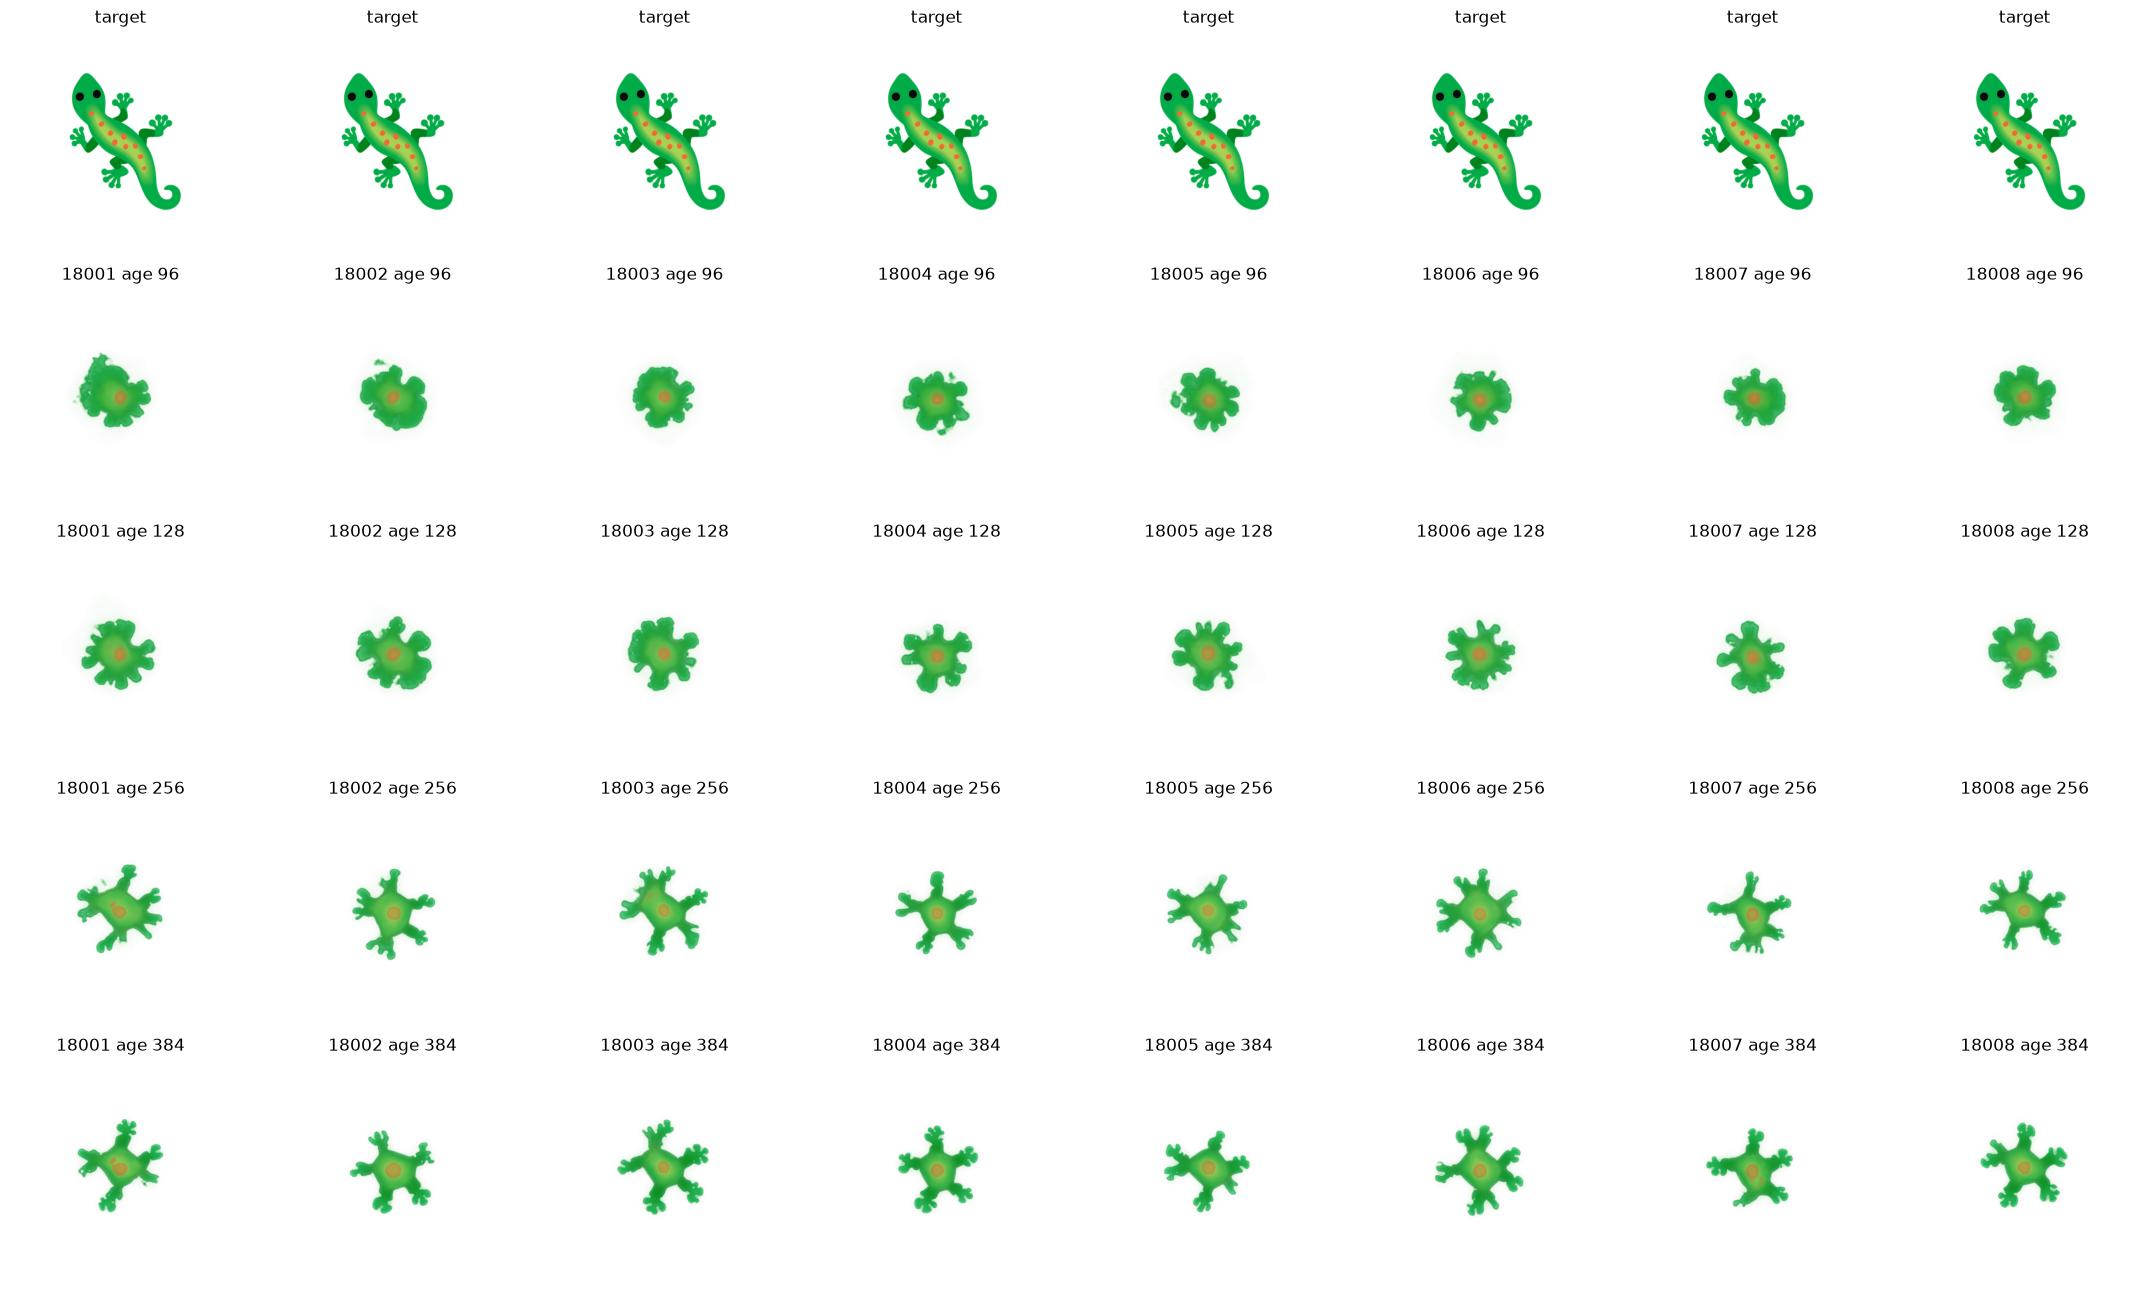

Age-128: {
  "l1": 0.04447769885882735,
  "l2": 0.02907007047906518,
  "shape_l1": 0.08853688230738044,
  "shape_l2": 0.0625145654194057,
  "lpips": 0.33460048772394657,
  "quality": 0.5591997047886252,
  "living_iou": 0.4063484323768769,
  "worst_quality": 0.5799759980291128
}
Persistence ratio: 0.9338966504547892
Pathwise D4: {
  "128": {
    "state_max_abs": 1.6361474990844727e-05,
    "image_max_abs": 0.00021189451217651367,
    "state_by_transform": [
      1.1213123798370361e-05,
      1.1391937732696533e-05,
      6.921589374542236e-06,
      1.6361474990844727e-05,
      3.2410025596618652e-06,
      3.822147846221924e-06,
      2.3944303393363953e-06
    ],
    "image_by_transform": [
      0.00014632940292358398,
      0.00014859437942504883,
      9.161233901977539e-05,
      0.00021189451217651367,
      4.374980926513672e-05,
      4.9233436584472656e-05,
      2.199411392211914e-05
    ],
    "pass_limit": true
  },
  "256": {
    "state_max_abs": 1.4871358871459961e-05,


In [9]:
#@title Select, lock, and audit without further optimization
selection_results = {}
for name, (model_path, decoder_path, step) in candidate_paths.items():
    candidate_model, candidate_decoder = make_system(model_path, decoder_path)
    result, _ = evaluate_checkpoint(
        candidate_model, candidate_decoder, SELECTION_SEEDS, SELECTION_AGES)
    q128 = result['by_age']['128']['quality']
    multi_age = float(np.mean([
        result['by_age'][str(age)]['quality'] for age in SELECTION_AGES]))
    result['step'] = step
    result['selection_key'] = [q128, multi_age]
    selection_results[name] = result
    print(name, '| age 128', f'{q128:.6f}', '| multi-age', f'{multi_age:.6f}')
    del candidate_model, candidate_decoder
    torch.cuda.empty_cache()

selected_name = min(selection_results,
                    key=lambda name: tuple(selection_results[name]['selection_key']))
selected_model_path, selected_decoder_path, selected_step = candidate_paths[selected_name]
torch.save(torch.load(selected_model_path, map_location='cpu', weights_only=True),
           OUTPUT_ROOT / 'model.pth')
torch.save(torch.load(selected_decoder_path, map_location='cpu', weights_only=True),
           OUTPUT_ROOT / 'decoder.pth')
selection = dict(
    selected_candidate=selected_name, selected_step=selected_step,
    results=selection_results)
(OUTPUT_ROOT / 'selection.json').write_text(json.dumps(selection, indent=2))
print('Locked', selected_name, 'before opening the final audit trajectories')

model, decoder = make_system(OUTPUT_ROOT / 'model.pth', OUTPUT_ROOT / 'decoder.pth')
audit, audit_images = evaluate_checkpoint(
    model, decoder, AUDIT_SEEDS, AUDIT_AGES, keep_images=True)

@torch.no_grad()
def pathwise_d4_audit(steps=256):
    set_all_seeds(BASE_SEED + 99)
    seed = model.seed(1, GRID_SIZE, GRID_SIZE).float()
    states = torch.cat([d4_apply(seed, index) for index in range(8)])
    base_masks = (
        torch.rand(steps, 1, 1, GRID_SIZE, GRID_SIZE, device=device) < 0.5
    ).float()
    snapshots = {}
    for age in range(1, steps + 1):
        masks = torch.cat([
            d4_apply(base_masks[age - 1], index) for index in range(8)])
        states, _ = model(states, update_mask=masks)
        if age not in (128, 256):
            continue
        images = render_state(model, decoder, states)[0]
        state_errors, image_errors = [], []
        for transform in range(1, 8):
            state_errors.append(float(
                (states[transform:transform + 1]
                 - d4_apply(states[:1], transform)).abs().max()))
            image_errors.append(float(
                (images[transform:transform + 1]
                 - d4_apply(images[:1], transform)).abs().max()))
        snapshots[str(age)] = dict(
            state_max_abs=max(state_errors), image_max_abs=max(image_errors),
            state_by_transform=state_errors, image_by_transform=image_errors,
            pass_limit=max(state_errors + image_errors) < PATHWISE_D4_LIMIT)
    return snapshots

pathwise_d4 = pathwise_d4_audit()
age128 = audit['by_age']['128']
early_quality = audit['by_age']['96']['quality']
mature_qualities = [audit['by_age'][str(age)]['quality'] for age in (192, 256, 384)]
persistence_ratio = max(mature_qualities) / max(age128['quality'], 1e-12)
sharp = bool(age128['quality'] <= SHARP_MEAN_LIMIT
             and age128['worst_quality'] <= SHARP_WORST_LIMIT)
stable = bool(early_quality <= EARLY_QUALITY_LIMIT
              and persistence_ratio <= PERSISTENCE_RATIO_LIMIT)
d4_pass = all(item['pass_limit'] for item in pathwise_d4.values())
material = bool(age128['quality'] <= PROGRESS_LIMIT and d4_pass)
if sharp and stable and d4_pass:
    decision = 'interrupted_checkpoint_is_sharp_stable_and_d4_valid'
elif sharp:
    decision = 'interrupted_checkpoint_is_sharp_but_behavior_gate_failed'
elif material:
    decision = 'interrupted_checkpoint_justifies_one_bounded_continuation'
else:
    decision = 'bounded_audit_supports_typed_d4_transition'

image_lookup = {(item['seed'], item['age']): item['rgba'] for item in audit_images}
target = canonical_target[0].detach().cpu().clamp(0, 1)
panel_ages = (96, 128, 256, 384)
fig, axes = plt.subplots(5, 8, figsize=(22, 13))
for column in range(8):
    axes[0, column].imshow(
        (target[:3] + 1 - target[3:4]).permute(1, 2, 0).clamp(0, 1))
    axes[0, column].set_title('target'); axes[0, column].axis('off')
for row_index, age in enumerate(panel_ages, 1):
    for column, seed in enumerate(AUDIT_SEEDS[:8]):
        rgba = image_lookup[(seed, age)].clamp(0, 1)
        axes[row_index, column].imshow(
            (rgba[:3] + 1 - rgba[3:4]).permute(1, 2, 0).clamp(0, 1))
        axes[row_index, column].set_title(f'{seed} age {age}')
        axes[row_index, column].axis('off')
fig.tight_layout()
panel_path = OUTPUT_ROOT / 'v17b3_post_lock_audit.png'
fig.savefig(panel_path, dpi=150)
plt.show(); plt.close(fig)

metrics = dict(
    status='complete', config=config, training_summary=training_summary,
    selection=selection, audit=audit, pathwise_d4=pathwise_d4,
    summary=dict(
        age128=age128, early_quality=early_quality,
        persistence_ratio=persistence_ratio, sharp=sharp, stable=stable,
        d4_pass=d4_pass, material_progress=material,
        ratio_to_v14a=age128['quality'] / V14A_QUALITY,
        ratio_to_v14c=age128['quality'] / V14C_AGE128_QUALITY),
    decision=decision)
(OUTPUT_ROOT / 'metrics.json').write_text(json.dumps(metrics, indent=2))
with tarfile.open(ARCHIVE_PATH, 'w:gz') as archive:
    for name in ('config.json', 'training_summary.json', 'selection.json',
                 'metrics.json', 'model.pth', 'decoder.pth',
                 'v17b3_post_lock_audit.png'):
        archive.add(OUTPUT_ROOT / name, arcname=SLUG + '/' + name)
print('Age-128:', json.dumps(age128, indent=2))
print('Persistence ratio:', persistence_ratio)
print('Pathwise D4:', json.dumps(pathwise_d4, indent=2))
print('Decision:', decision)
print('Download:', ARCHIVE_PATH)
